## Modified notebook
Use Random Forest trained on same preprocessing as deployment.

In [11]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Display plots inside notebook
%matplotlib inline
df = pd.read_excel("flood_dataset.xlsx")
df.head()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
0,29,70,30,3248.6,73.4,386.2,2122.8,666.1,274.866667,649.9,0
1,28,75,40,3326.6,9.3,275.7,2403.4,638.2,130.300000,256.4,1
2,28,75,42,3271.2,21.7,336.3,2343.0,570.1,186.200000,308.9,0
3,29,71,44,3129.7,26.7,339.4,2398.2,365.3,366.066667,862.5,0
4,31,74,40,2741.6,23.4,378.5,1881.5,458.1,283.400000,586.9,0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temp         115 non-null    int64  
 1   Humidity     115 non-null    int64  
 2   Cloud Cover  115 non-null    int64  
 3   ANNUAL       115 non-null    float64
 4   Jan-Feb      115 non-null    float64
 5   Mar-May      115 non-null    float64
 6   Jun-Sep      115 non-null    float64
 7   Oct-Dec      115 non-null    float64
 8   avgjune      115 non-null    float64
 9   sub          115 non-null    float64
 10  flood        115 non-null    int64  
dtypes: float64(7), int64(4)
memory usage: 10.0 KB


In [13]:
print(df.columns)

Index(['Temp', 'Humidity', 'Cloud Cover', 'ANNUAL', 'Jan-Feb', 'Mar-May',
       'Jun-Sep', 'Oct-Dec', 'avgjune', 'sub', 'flood'],
      dtype='object')


In [14]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 115
Columns: 11


In [15]:
df.isnull().sum()

Temp           0
Humidity       0
Cloud Cover    0
ANNUAL         0
Jan-Feb        0
Mar-May        0
Jun-Sep        0
Oct-Dec        0
avgjune        0
sub            0
flood          0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.describe()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
count,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000
mean,29.600000,73.852174,36.286957,2925.487826,27.739130,377.253913,2022.840870,497.636522,218.100870,439.801739,0.139130
std,1.122341,2.947623,4.330158,422.112193,22.361032,151.091850,386.254397,129.860643,62.547597,210.438813,0.347597
min,28.000000,70.000000,30.000000,2068.800000,0.300000,89.900000,1104.300000,166.600000,65.600000,34.200000,0.000000
25%,29.000000,71.000000,32.500000,2627.900000,10.250000,276.750000,1768.850000,407.450000,179.666667,295.000000,0.000000
50%,30.000000,74.000000,36.000000,2937.500000,20.500000,342.000000,1948.700000,501.500000,211.033333,430.600000,0.000000
75%,31.000000,76.000000,40.000000,3164.100000,41.600000,442.300000,2242.900000,584.550000,263.833333,577.650000,0.000000
max,31.000000,79.000000,44.000000,4257.800000,98.100000,915.200000,3451.300000,823.300000,366.066667,982.700000,1.000000


In [18]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (115, 11)


In [19]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


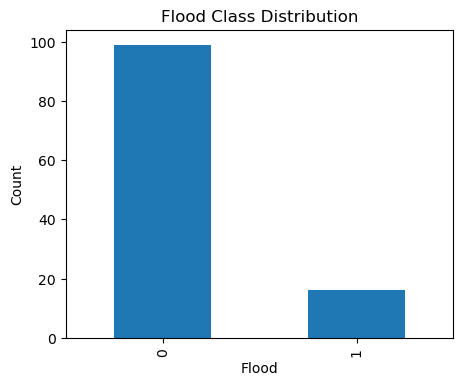

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
df['flood'].value_counts().plot(kind='bar')
plt.title("Flood Class Distribution")
plt.xlabel("Flood")
plt.ylabel("Count")
plt.show()

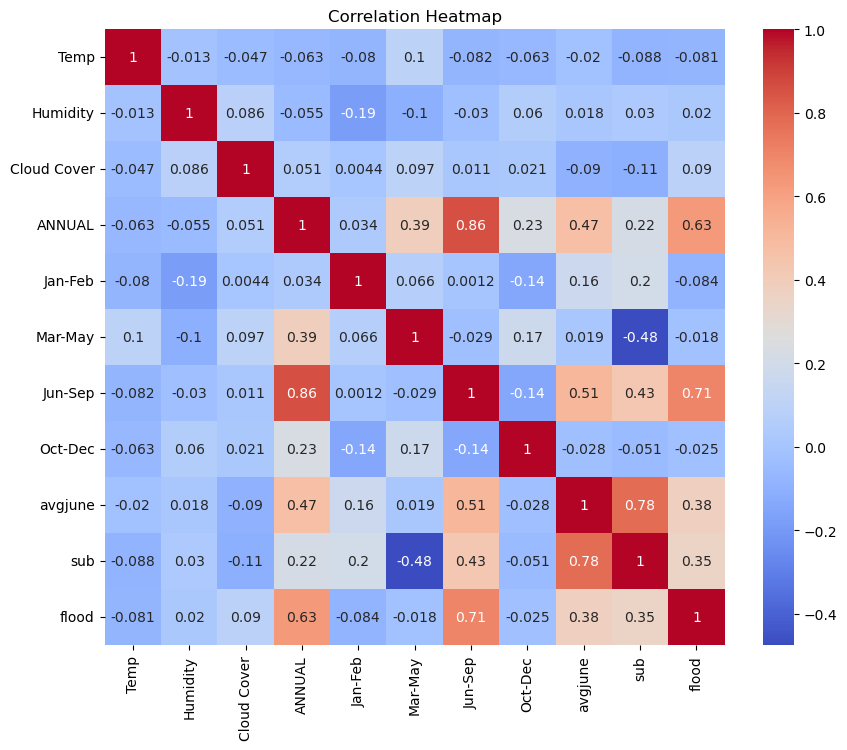

In [21]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

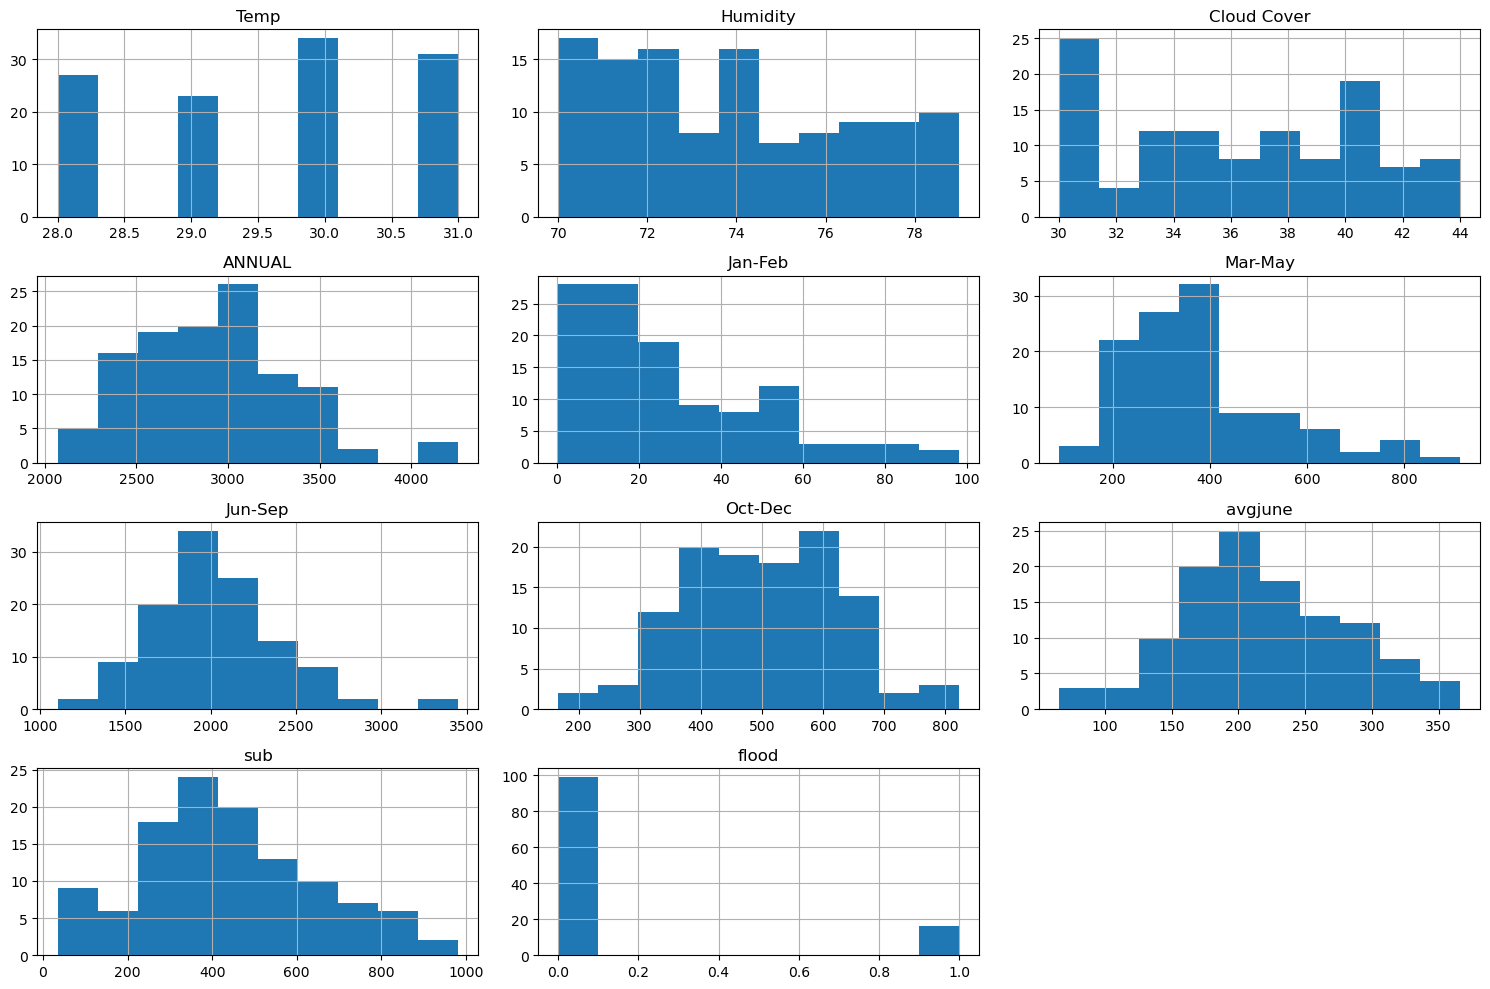

In [22]:
df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

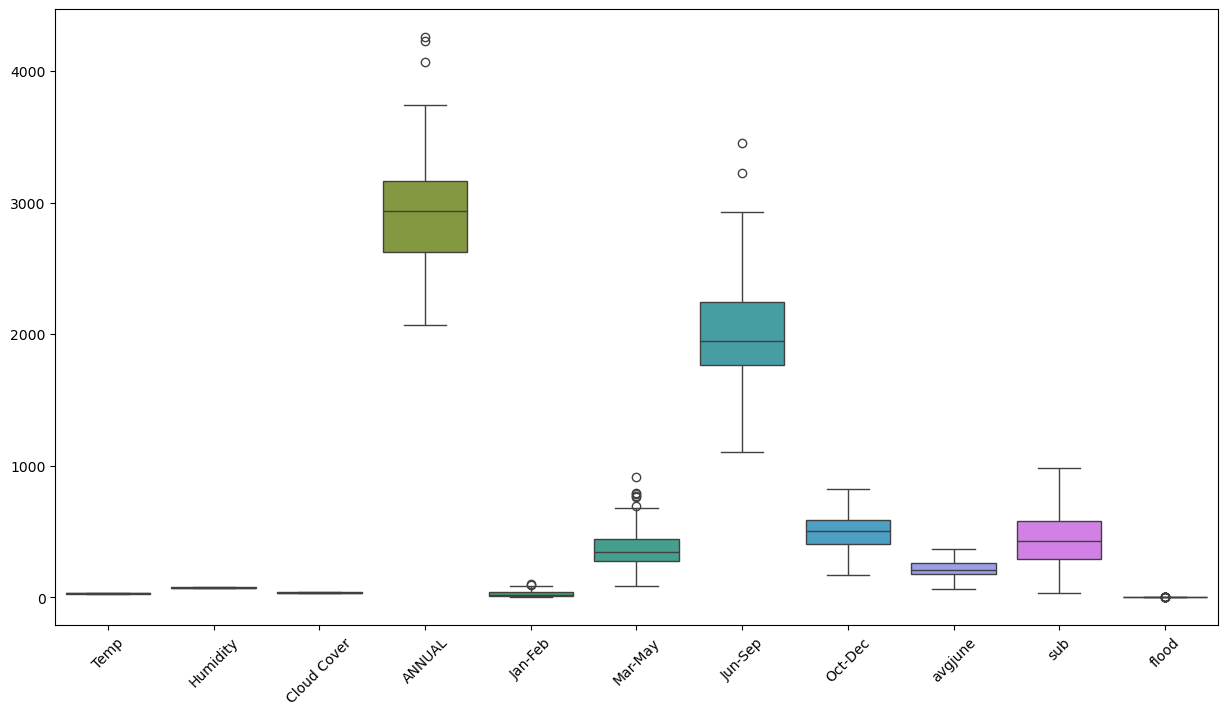

In [23]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

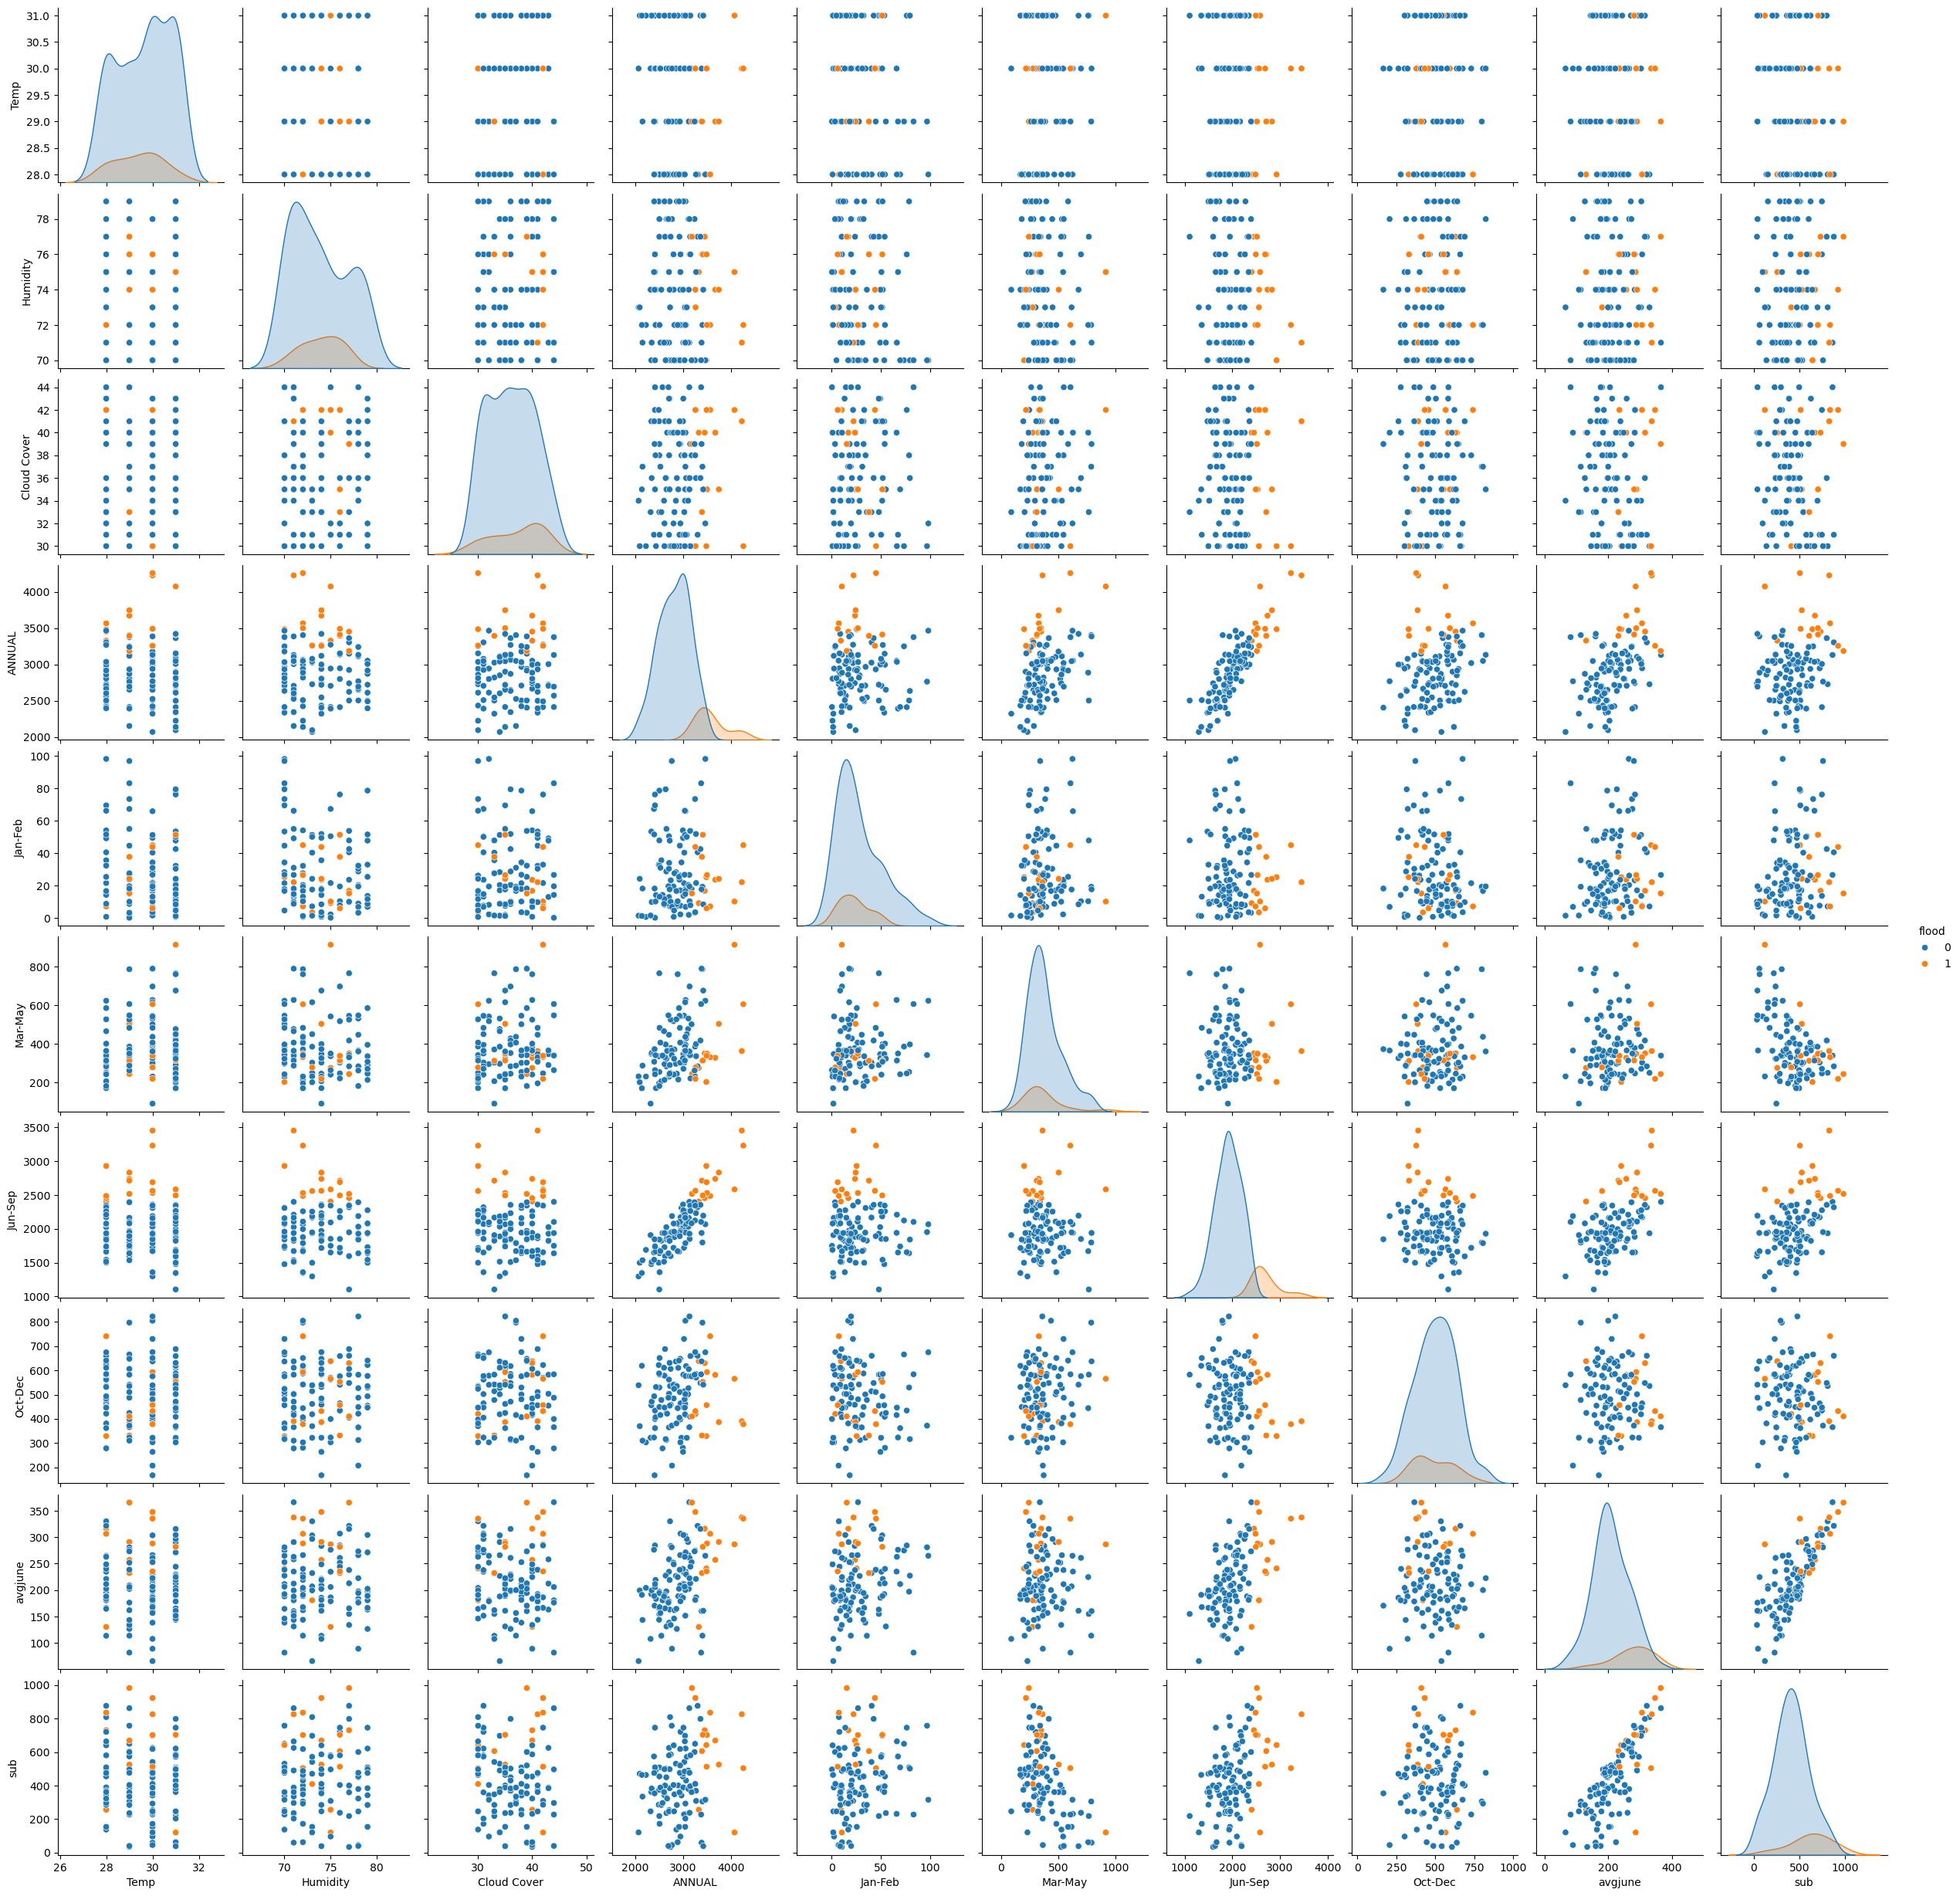

In [25]:
sns.pairplot(df, hue='flood')
plt.show()

In [26]:
# Features
X = df.drop("flood", axis=1)

# Target
y = df["flood"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (115, 10)
y Shape: (115,)


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 92
Testing samples: 23


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
print(X_train_scaled[:5])

[[ 1.18780995  1.3123629   1.14227916 -0.53320538  0.14848678  0.44288851
  -0.45944179 -0.95169783 -0.75996069 -0.95518953]
 [ 0.29936674 -1.36325786  0.44168127 -0.52257097  0.315421   -0.97471146
  -0.24055714  0.09472634 -1.45475609 -0.91644675]
 [ 0.29936674  1.3123629  -0.25891661  0.47895446 -0.35695294 -0.1223282
  -0.28066828  2.57249283  0.00292927  0.17619753]
 [-1.47751969  0.64345771 -1.19304712  0.0382171  -0.90412622 -0.49675171
   0.36270383 -0.18877624  1.46119171  1.374281  ]
 [ 1.18780995  0.64345771 -0.25891661  1.13828809  1.11763266 -0.42837872
   1.22017912  0.49193728  1.02723312  1.2884584 ]]


In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [31]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_prediction = dt_model.predict(X_test)

In [32]:
print("Decision Tree Accuracy :",
      accuracy_score(y_test, dt_prediction))

Decision Tree Accuracy : 0.9565217391304348


In [33]:
cm = confusion_matrix(y_test, dt_prediction)

print(cm)

[[20  0]
 [ 1  2]]


In [34]:
print(classification_report(y_test, dt_prediction))

              precision    recall  f1-score   support

           0       0.95      1.00      0.98        20
           1       1.00      0.67      0.80         3

    accuracy                           0.96        23
   macro avg       0.98      0.83      0.89        23
weighted avg       0.96      0.96      0.95        23



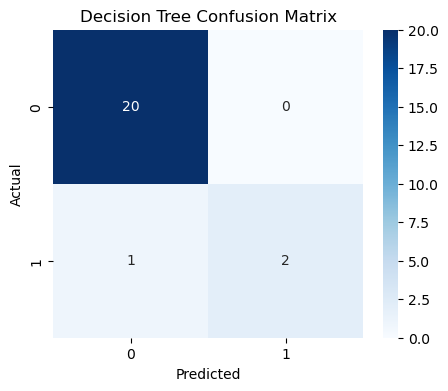

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

In [36]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_prediction = rf_model.predict(X_test)

print("Random Forest Accuracy :",
      accuracy_score(y_test, rf_prediction))

print(confusion_matrix(y_test, rf_prediction))

print(classification_report(y_test, rf_prediction))

Random Forest Accuracy : 0.9565217391304348
[[20  0]
 [ 1  2]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.98        20
           1       1.00      0.67      0.80         3

    accuracy                           0.96        23
   macro avg       0.98      0.83      0.89        23
weighted avg       0.96      0.96      0.95        23



In [37]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

knn_prediction = knn_model.predict(X_test_scaled)

print("KNN Accuracy :",
      accuracy_score(y_test, knn_prediction))

print(confusion_matrix(y_test, knn_prediction))

print(classification_report(y_test, knn_prediction))

KNN Accuracy : 0.8695652173913043
[[19  1]
 [ 2  1]]
              precision    recall  f1-score   support

           0       0.90      0.95      0.93        20
           1       0.50      0.33      0.40         3

    accuracy                           0.87        23
   macro avg       0.70      0.64      0.66        23
weighted avg       0.85      0.87      0.86        23



In [38]:
accuracy = {
    "Decision Tree":
        accuracy_score(y_test, dt_prediction),

    "Random Forest":
        accuracy_score(y_test, rf_prediction),

    "KNN":
        accuracy_score(y_test, knn_prediction)
}

print(accuracy)

{'Decision Tree': 0.9565217391304348, 'Random Forest': 0.9565217391304348, 'KNN': 0.8695652173913043}


In [41]:
X = df.drop("flood", axis=1)
y = df["flood"]

In [42]:
from xgboost import XGBClassifier

In [43]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

xgb_prediction = xgb_model.predict(X_test)

In [44]:
print("XGBoost Accuracy:",
      accuracy_score(y_test, xgb_prediction))

print(confusion_matrix(y_test, xgb_prediction))

print(classification_report(y_test, xgb_prediction))

XGBoost Accuracy: 0.8695652173913043
[[20  0]
 [ 3  0]]
              precision    recall  f1-score   support

           0       0.87      1.00      0.93        20
           1       0.00      0.00      0.00         3

    accuracy                           0.87        23
   macro avg       0.43      0.50      0.47        23
weighted avg       0.76      0.87      0.81        23



In [45]:
accuracy = {
    "Decision Tree": accuracy_score(y_test, dt_prediction),
    "Random Forest": accuracy_score(y_test, rf_prediction),
    "KNN": accuracy_score(y_test, knn_prediction),
    "XGBoost": accuracy_score(y_test, xgb_prediction)
}

for model, score in accuracy.items():
    print(f"{model}: {score:.4f}")

Decision Tree: 0.9565
Random Forest: 0.9565
KNN: 0.8696
XGBoost: 0.8696


In [46]:
import joblib

joblib.dump(xgb_model, "floods.save")
joblib.dump(scaler, "scaler.save")

print("Model saved successfully!")

Model saved successfully!


In [49]:
probabilities = xgb_model.predict_proba(X_test)

print(probabilities[:5])

[[0.9875717 0.0124283]
 [0.9875717 0.0124283]
 [0.9875717 0.0124283]
 [0.9875717 0.0124283]
 [0.9875717 0.0124283]]


In [50]:
import joblib

joblib.dump(rf_model, "floods.save")
joblib.dump(scaler, "scaler.save")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [ ]:
model = joblib.load("floods.save")
print(type(model))
print(hasattr(model, "predict_proba"))